# Weather Australia Rain Prediction

## Machine Learning Project

This project aims to predict whether it will rain tomorrow using historical weather observations collected from different locations across Australia.

## Problem UnderstandingThis is a **binary classification** problem: predict `RainTomorrow` (Yes/No) for a given Australian weather station using same-day weather observations.**Why it matters:** short-term rain forecasting from routine measurements (temperature, humidity, pressure, wind, cloud cover) supports everyday decisions in agriculture, transport, and event planning.**Framing decisions:**- The target is moderately imbalanced (~78% No / ~22% Yes), so **F1-score** (not accuracy) is used as the primary evaluation metric, and `class_weight="balanced"` is applied where the model supports it.- `RISK_MM` (tomorrow's rainfall amount) is dropped entirely, since it directly encodes the label (`RainTomorrow` is derived from whether `RISK_MM > 1mm`) — keeping it would be data leakage.

# Import Libraries

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Load Dataset

In [3]:
df_o=pd.read_csv("weatherAUS.csv")
df=df_o.copy()

In [4]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


### About this dataset

The dataset contains daily weather observations collected from multiple Australian locations.

# Dataset Overview

In [5]:
df.shape

(142193, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [7]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


In [8]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013


### Note

The dataset contains both numerical and categorical features with some missing values that require preprocessing.

# Data Cleaning

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df.drop(columns=["Date"], inplace=True)

In [11]:
df.drop(columns=["RISK_MM"], inplace=True)

In [12]:
df.dropna(subset=["RainTomorrow"], inplace=True)

df.reset_index(drop=True, inplace=True)

# Missing Values Analysis

In [13]:
df.isnull().sum().sort_values(ascending=False)

,0
Sunshine,67816
Evaporation,60843
Cloud3pm,57094
Cloud9am,53657
Pressure9am,14014
Pressure3pm,13981
WindDir9am,10013
WindGustDir,9330
WindGustSpeed,9270
WindDir3pm,3778


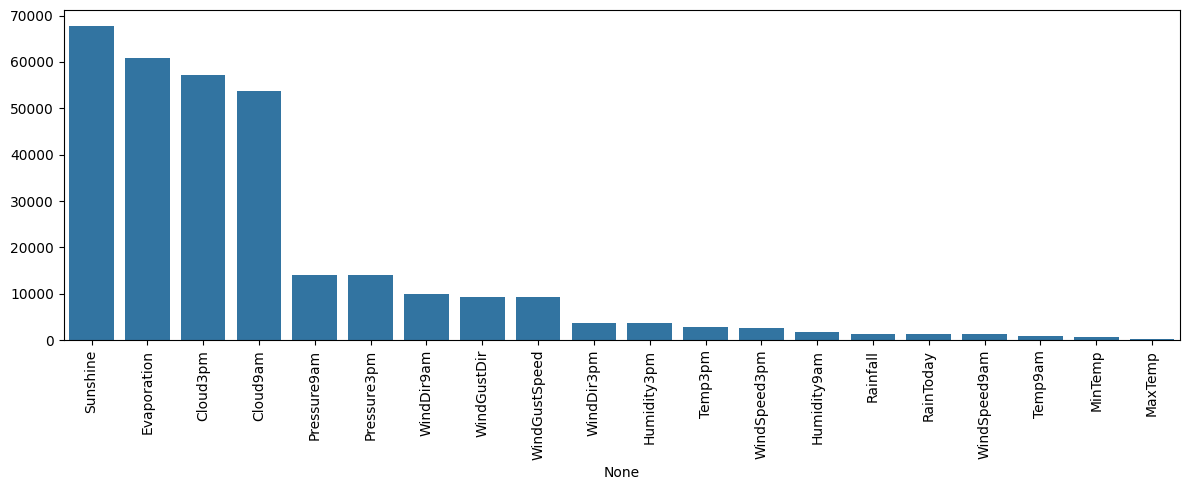

In [14]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12,5))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

### Note`Sunshine` (47.7%) and `Evaporation` (42.8%) have by far the highest missing rates, followed by `Cloud3pm` (40.2%) and `Cloud9am` (37.7%). `Pressure9am`/`Pressure3pm` are missing ~9.8%, and most remaining columns are below 3%. These will be handled with median (numeric) / most-frequent (categorical) imputation.

# Target Distribution

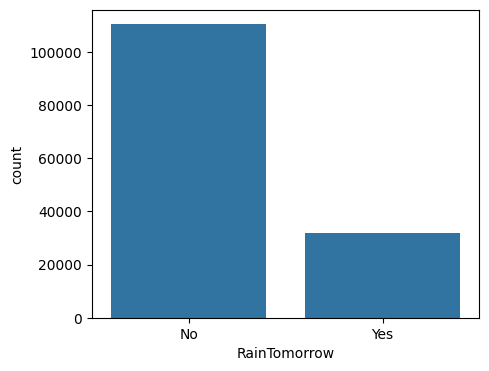

In [15]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="RainTomorrow"
)

plt.show()

In [16]:
df["RainTomorrow"].value_counts(normalize=True) * 100

,proportion
RainTomorrow,
No,77.581878
Yes,22.418122


### Note`RainTomorrow` is moderately imbalanced: **77.6% "No"** vs **22.4% "Yes"**. This isn't severe enough to justify resampling (e.g. SMOTE), but it does mean accuracy alone would be misleading — F1-score and `class_weight="balanced"` are used to keep the minority ("Yes") class from being ignored.

# Train Test Split

In [17]:
x = df.drop("RainTomorrow", axis=1)

y = df["RainTomorrow"]

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print(x_train.shape)

print(x_test.shape)

(113754, 24)
(28439, 24)


# Feature Engineering

In [20]:
x_train["TempDifference"] = x_train["MaxTemp"] - x_train["MinTemp"]

x_test["TempDifference"] = x_test["MaxTemp"] - x_test["MinTemp"]
x_train["HumidityDifference"] = x_train["Humidity3pm"] - x_train["Humidity9am"]

x_test["HumidityDifference"] = x_test["Humidity3pm"] - x_test["Humidity9am"]
x_train["PressureDifference"] = x_train["Pressure3pm"] - x_train["Pressure9am"]

x_test["PressureDifference"] = x_test["Pressure3pm"] - x_test["Pressure9am"]
x_train["WindSpeedDifference"] = x_train["WindSpeed3pm"] - x_train["WindSpeed9am"]

x_test["WindSpeedDifference"] = x_test["WindSpeed3pm"] - x_test["WindSpeed9am"]

### Note

New weather difference features may improve the model's ability to capture weather changes during the day.

# Feature Types

In [21]:
numerical_columns = x_train.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_columns = x_train.select_dtypes(
    include="object"
).columns.tolist()

# Missing Value Imputation

In [22]:
num_imputer = SimpleImputer(
    strategy="median"
)

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

In [23]:
x_train[numerical_columns] = num_imputer.fit_transform(
    x_train[numerical_columns]
)

x_test[numerical_columns] = num_imputer.transform(
    x_test[numerical_columns]
)

In [24]:
x_train[categorical_columns] = cat_imputer.fit_transform(
    x_train[categorical_columns]
)

x_test[categorical_columns] = cat_imputer.transform(
    x_test[categorical_columns]
)

In [25]:
print(x_train.isnull().sum().sum())

print(x_test.isnull().sum().sum())

0
0


# Outliers handling

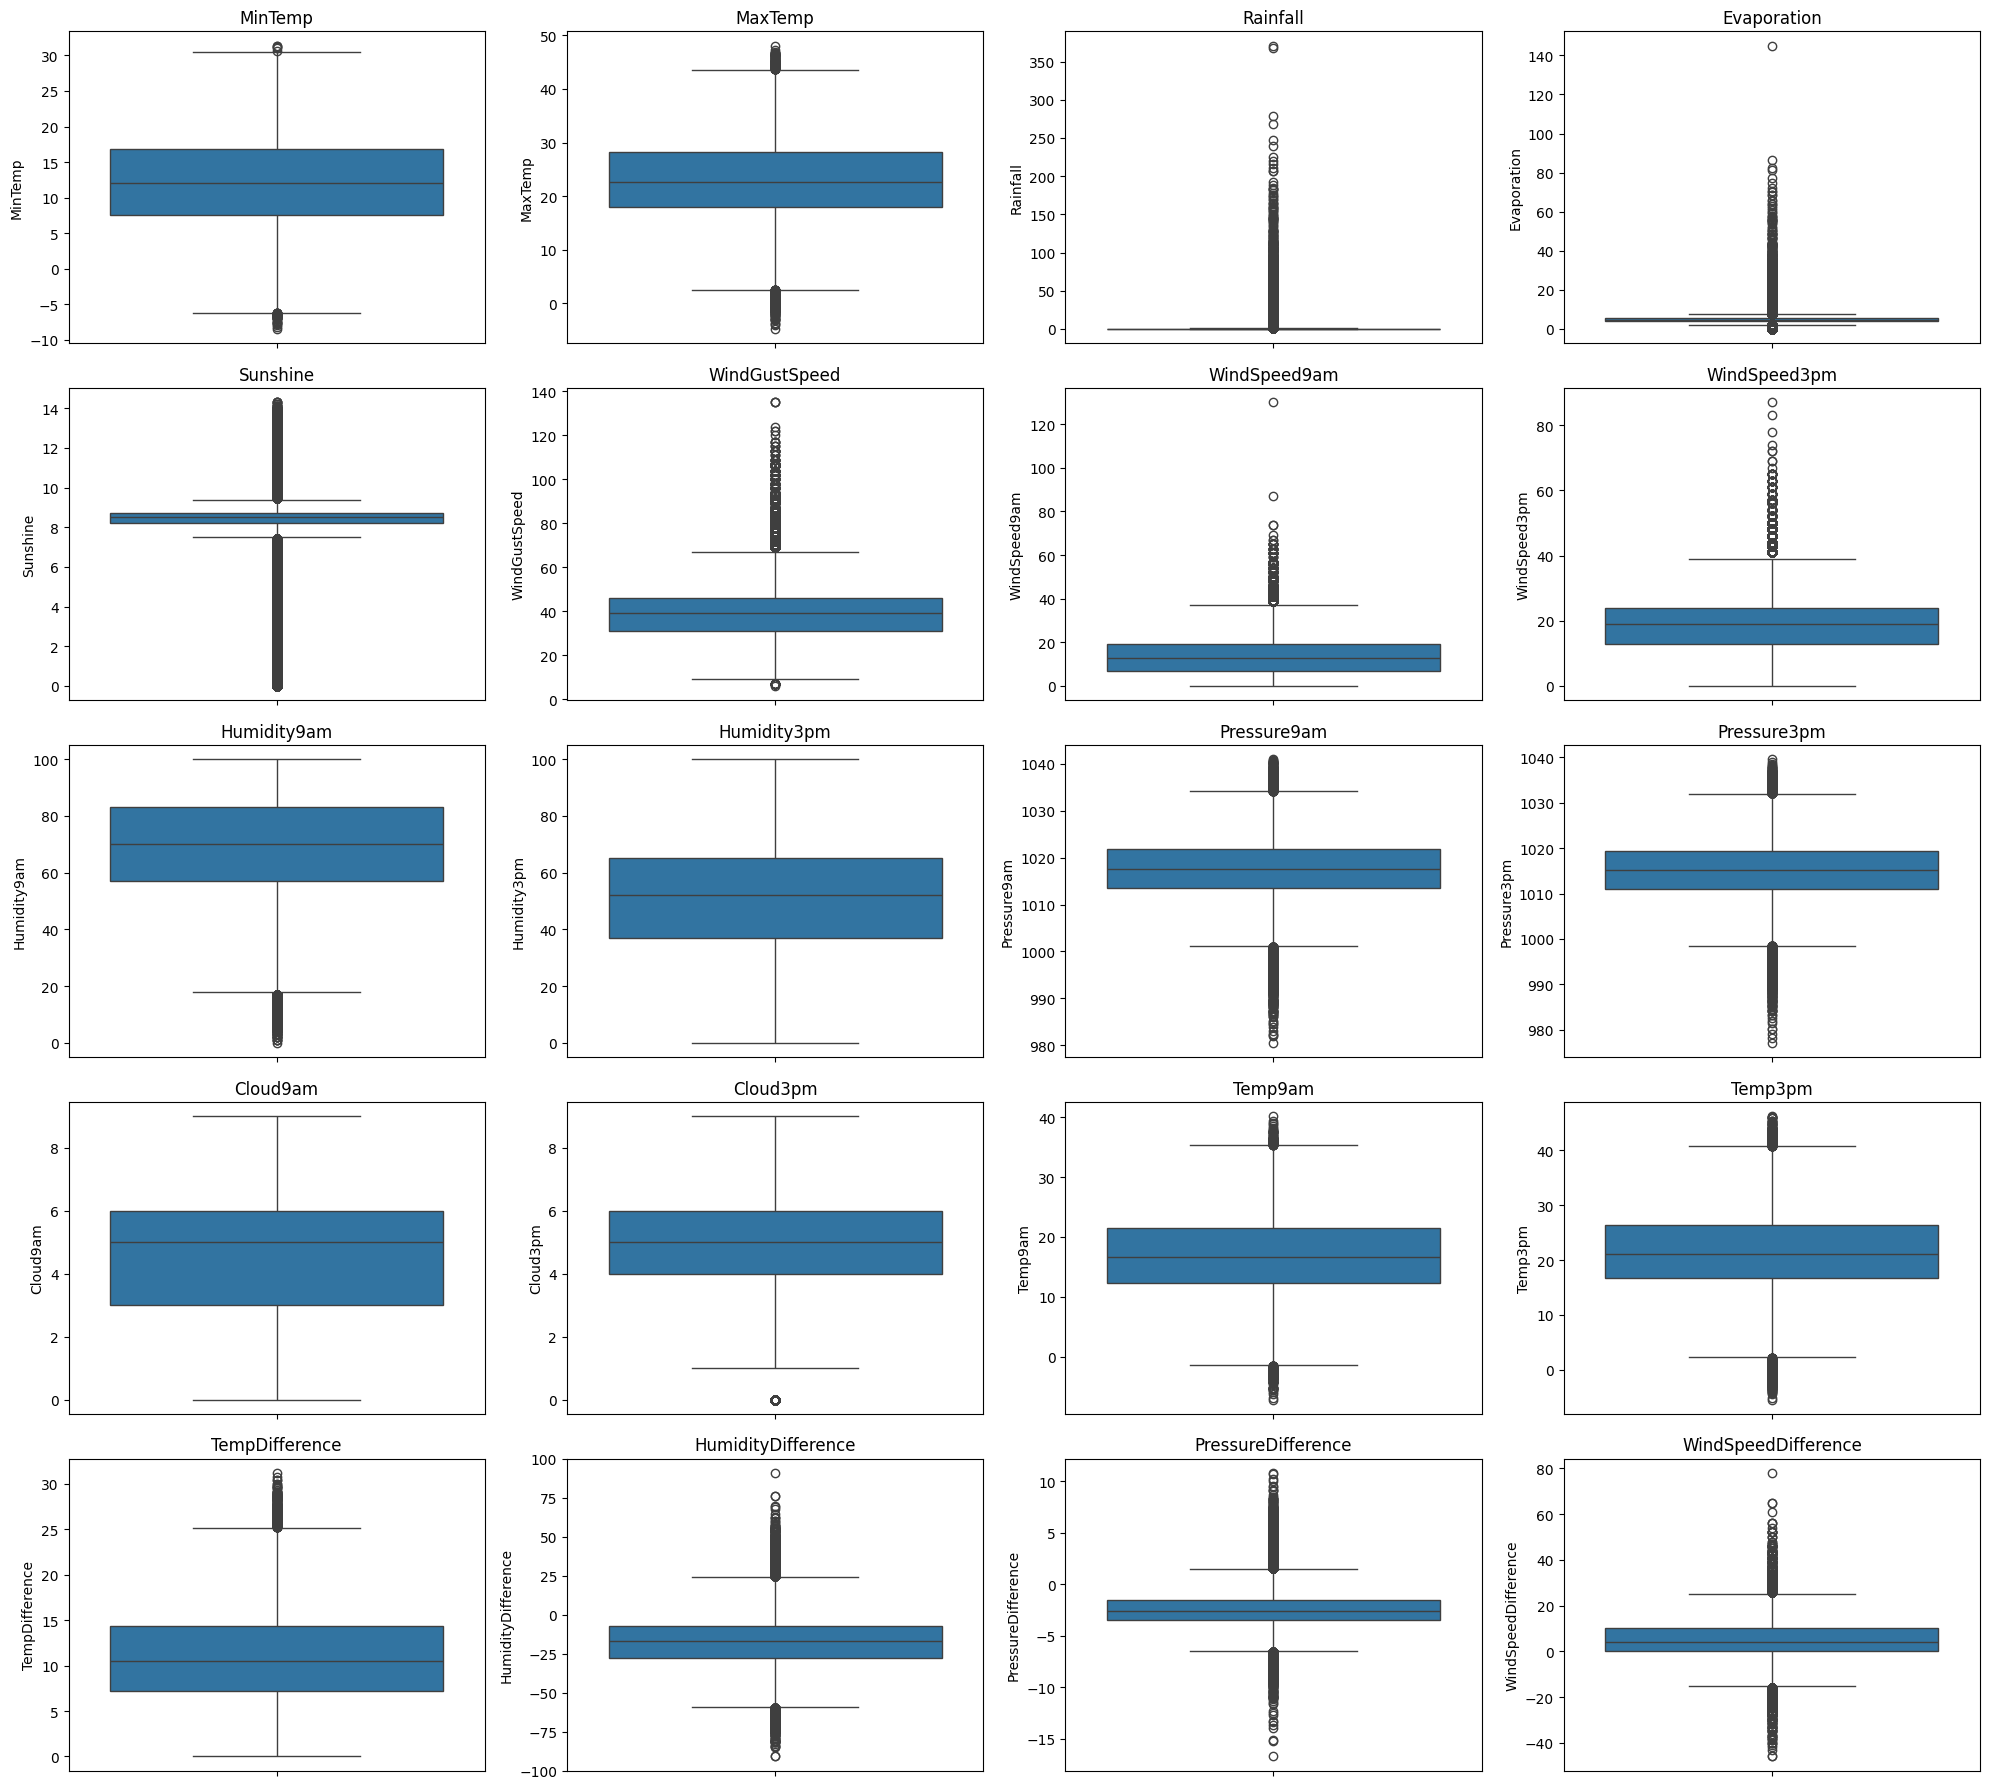

In [26]:
plt.figure(figsize=(20,18))

for i, column in enumerate(numerical_columns):

    plt.subplot(5,4,i+1)

    sns.boxplot(
        y=x_train[column]
    )

    plt.title(column)

plt.tight_layout()

plt.show()

In [27]:
for column in numerical_columns:

    Q1 = x_train[column].quantile(0.25)

    Q3 = x_train[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    x_train[column] = x_train[column].clip(lower, upper)

    x_test[column] = x_test[column].clip(lower, upper)

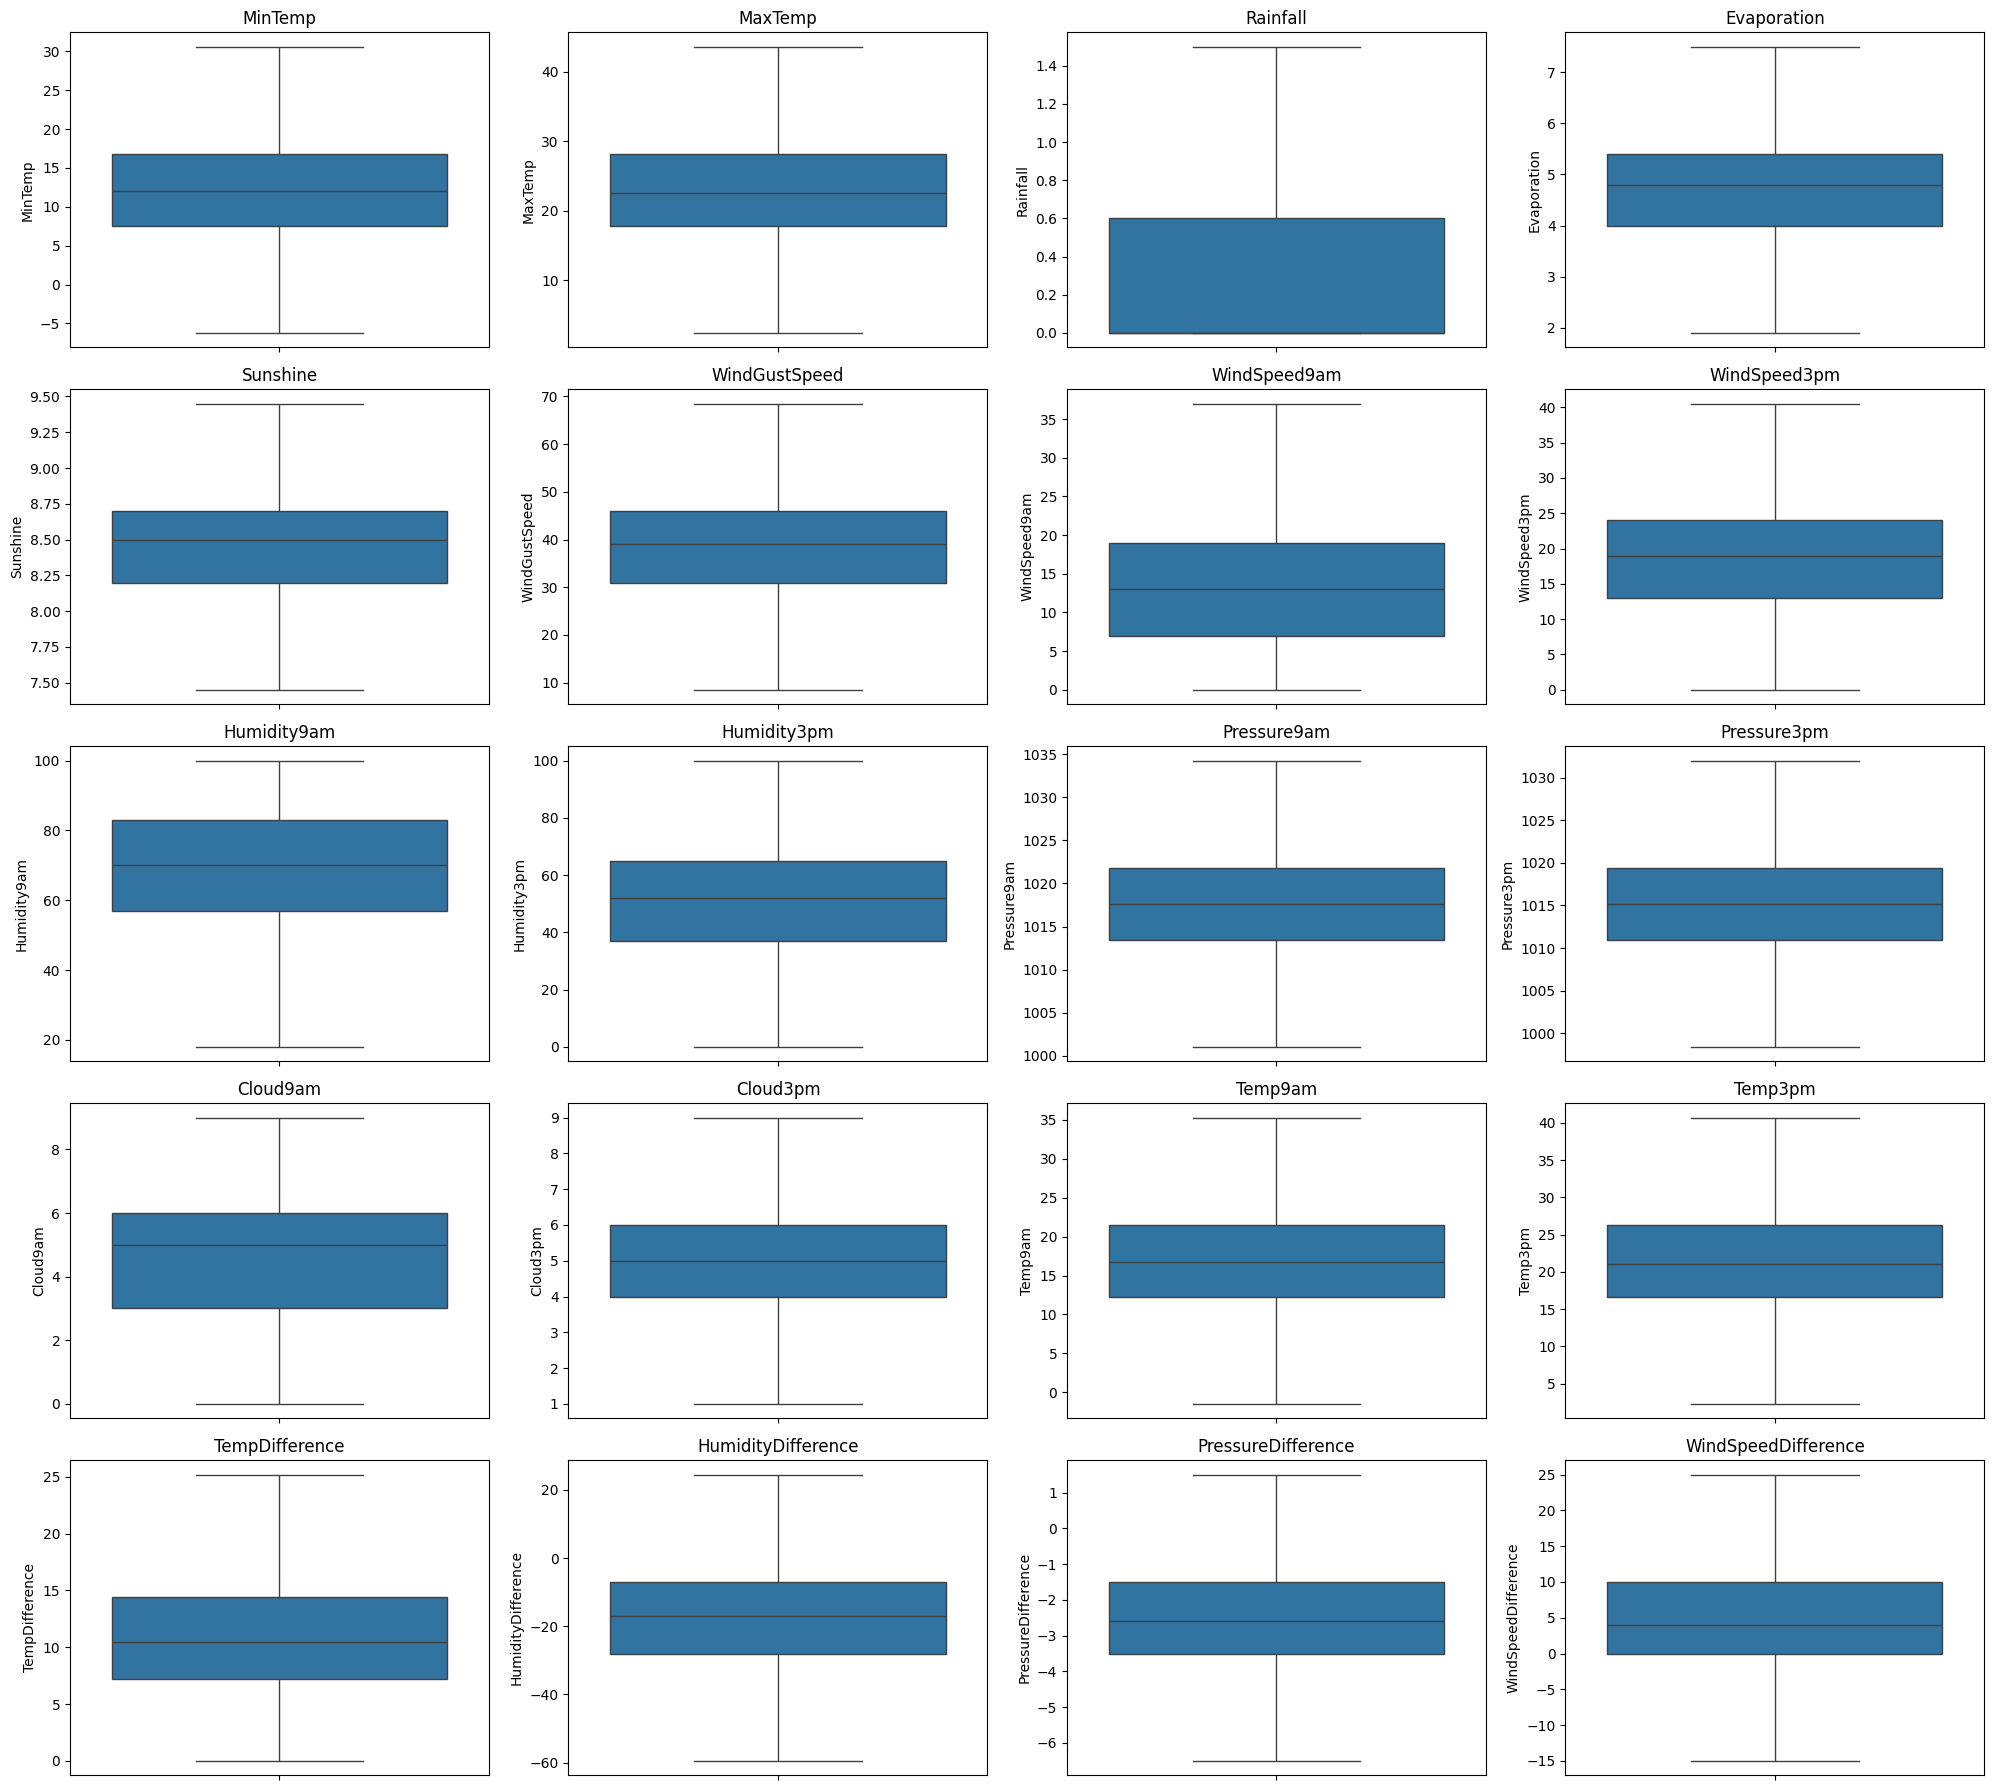

In [28]:
plt.figure(figsize=(20,18))

for i, column in enumerate(numerical_columns):

    plt.subplot(5,4,i+1)

    sns.boxplot(
        y=x_train[column]
    )

    plt.title(column)

plt.tight_layout()

plt.show()

### Note

Extreme values were capped using the IQR method to reduce their impact on model performance.

# Feature Distribution

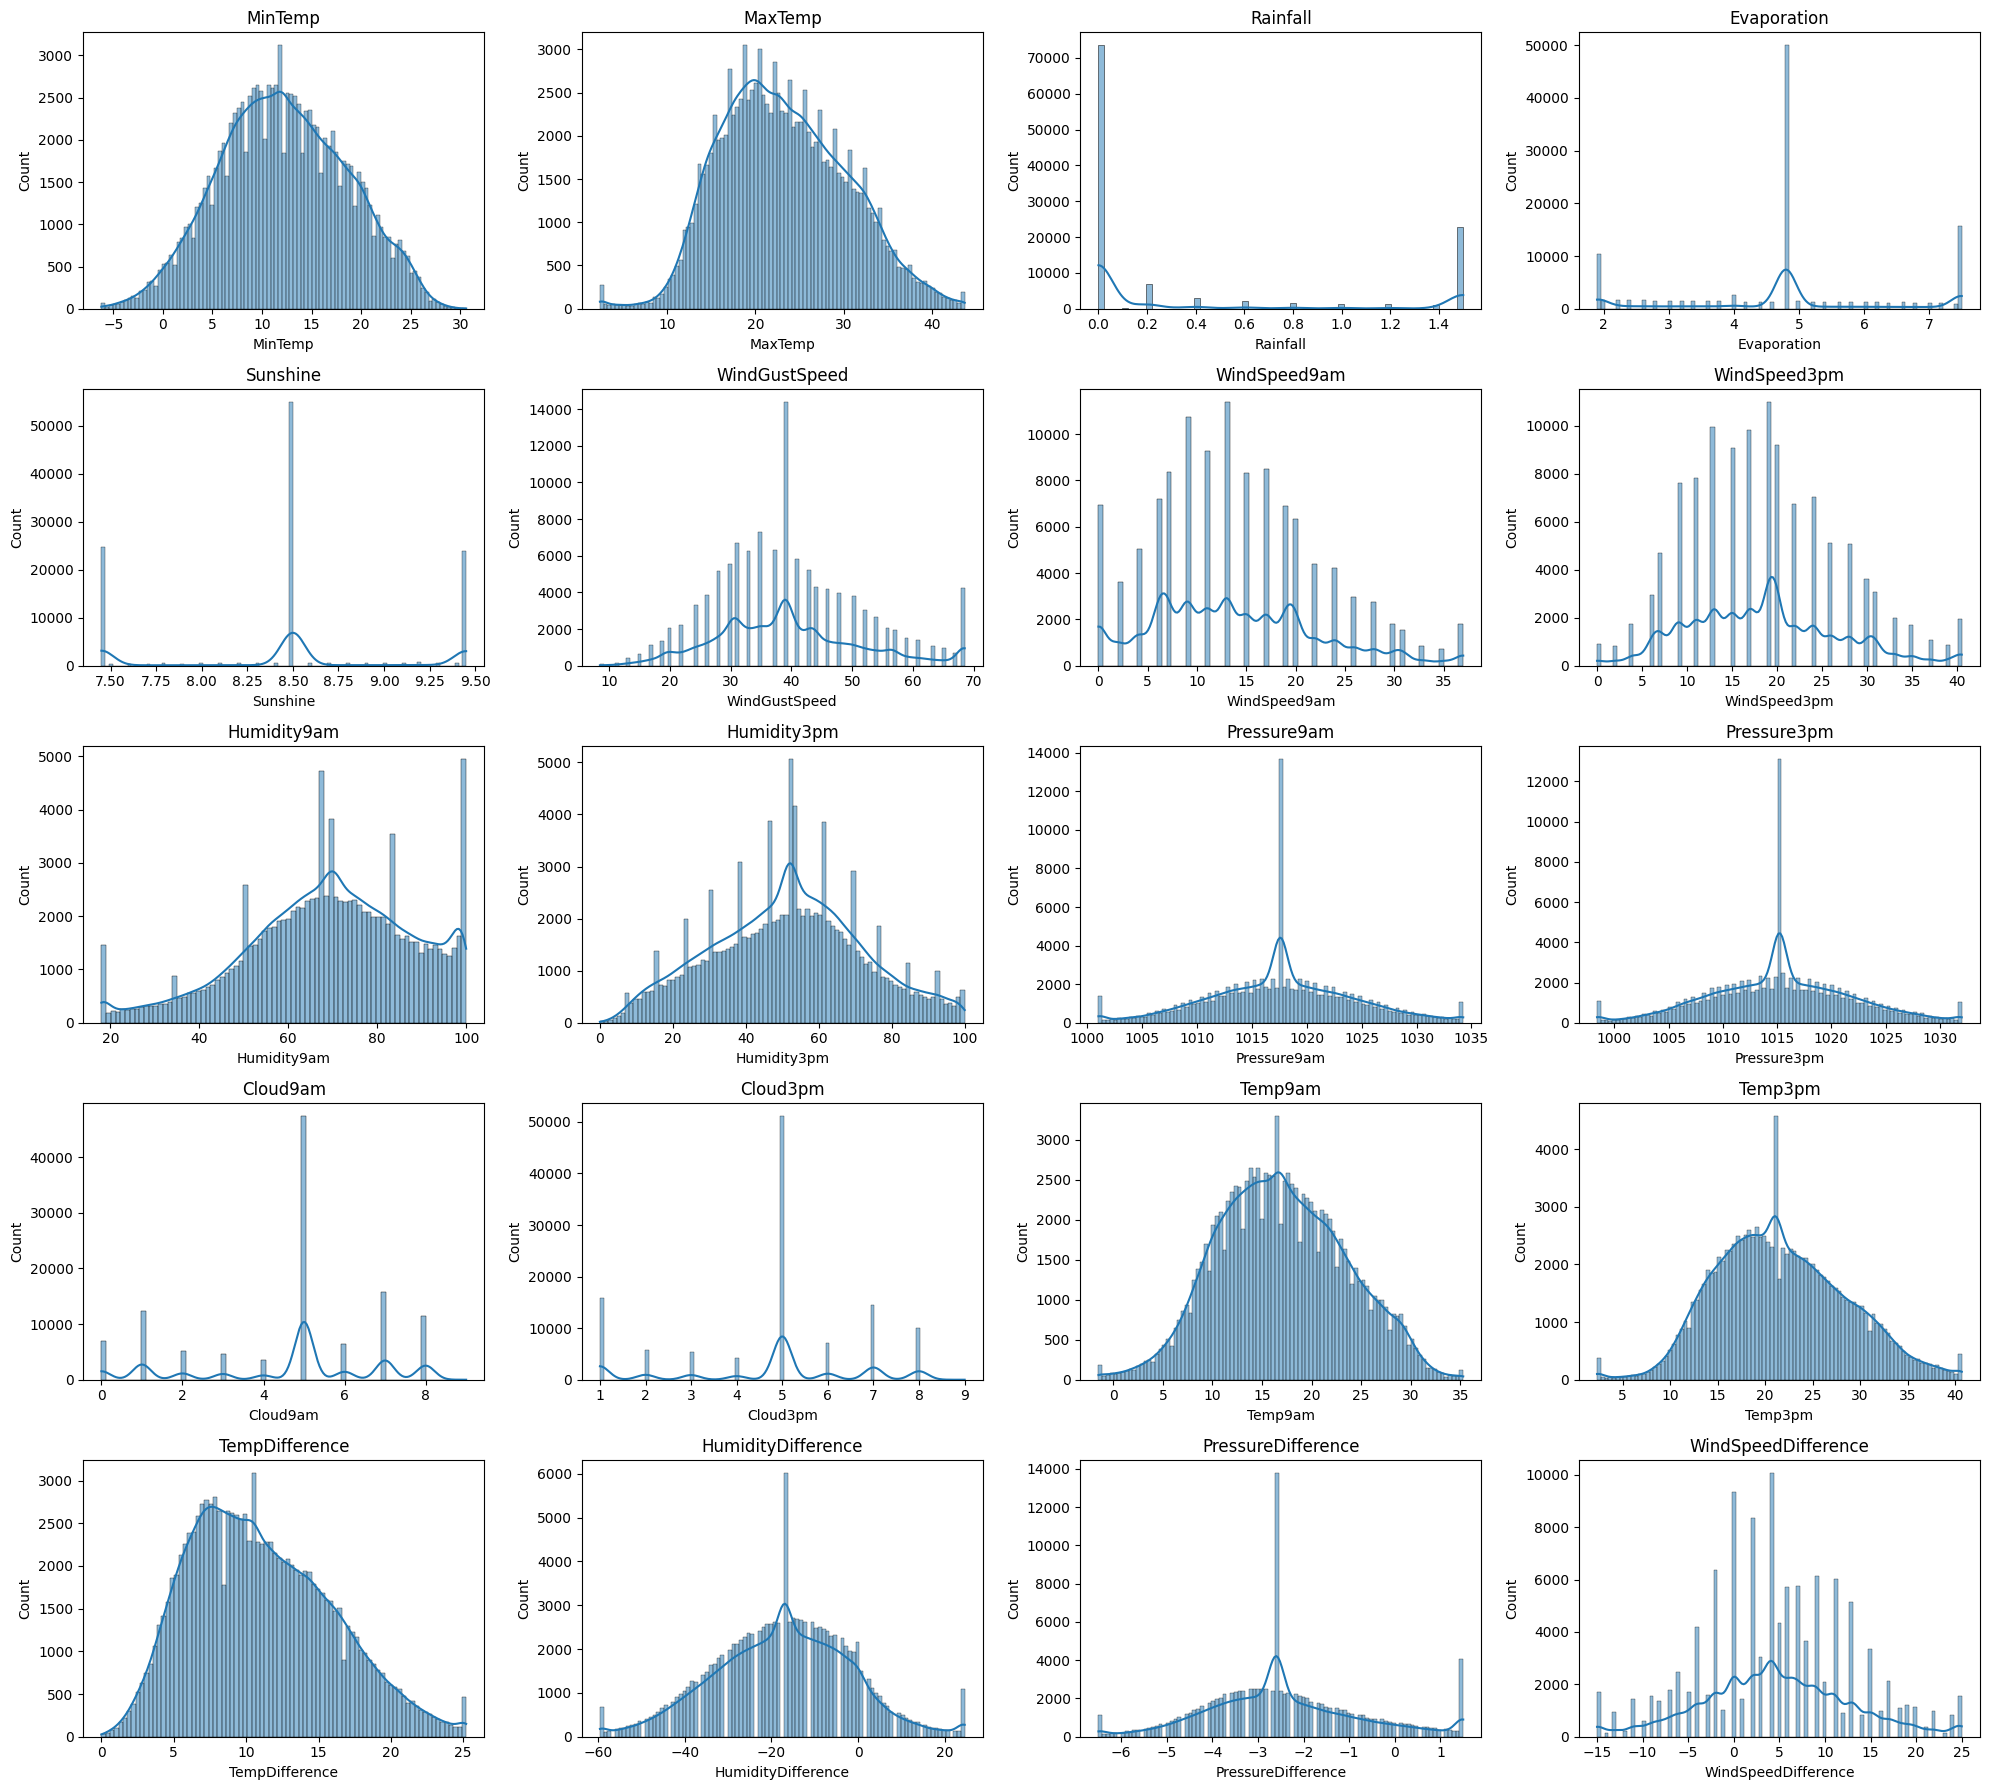

In [29]:
plt.figure(figsize=(20,18))

for i, column in enumerate(numerical_columns):

    plt.subplot(5,4,i+1)

    sns.histplot(
        x=x_train[column],
        kde=True
    )

    plt.title(column)

plt.tight_layout()

plt.show()

### Note

Most numerical features show skewed distributions, which is common in weather datasets.

# Categorical Feature Distribution

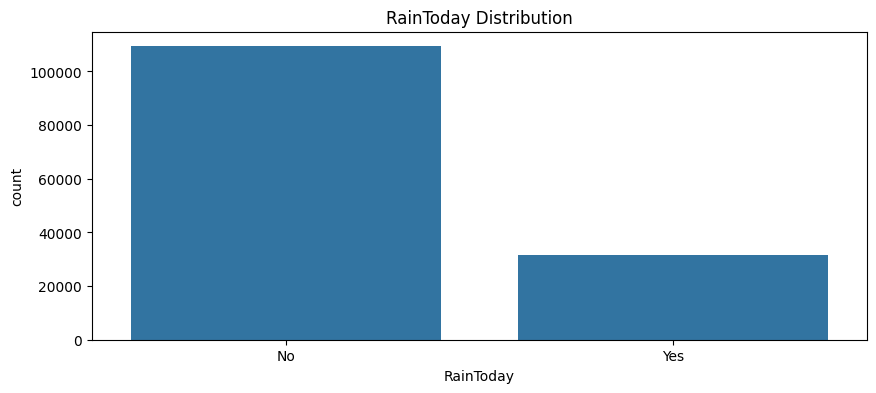

In [30]:
plt.figure(figsize=(10,4))

sns.countplot(
    data=df,
    x="RainToday",
    order=["No","Yes"]
)

plt.title("RainToday Distribution")

plt.show()

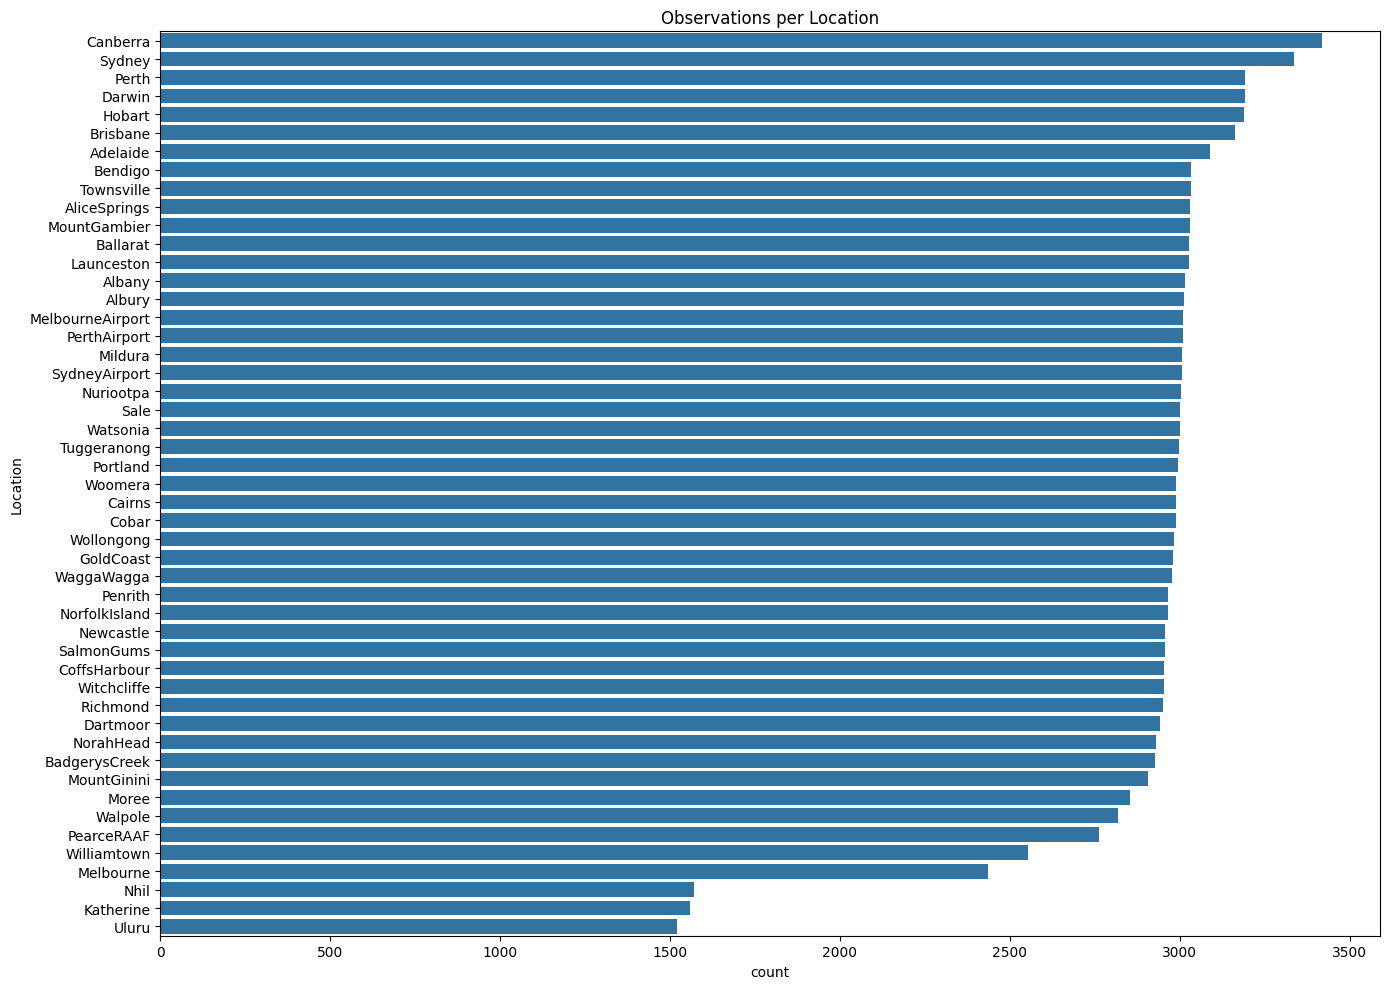

In [31]:
plt.figure(figsize=(14,10))

sns.countplot(
    data=df,
    y="Location",
    order=df["Location"].value_counts().index
)

plt.title("Observations per Location")

plt.tight_layout()

plt.show()

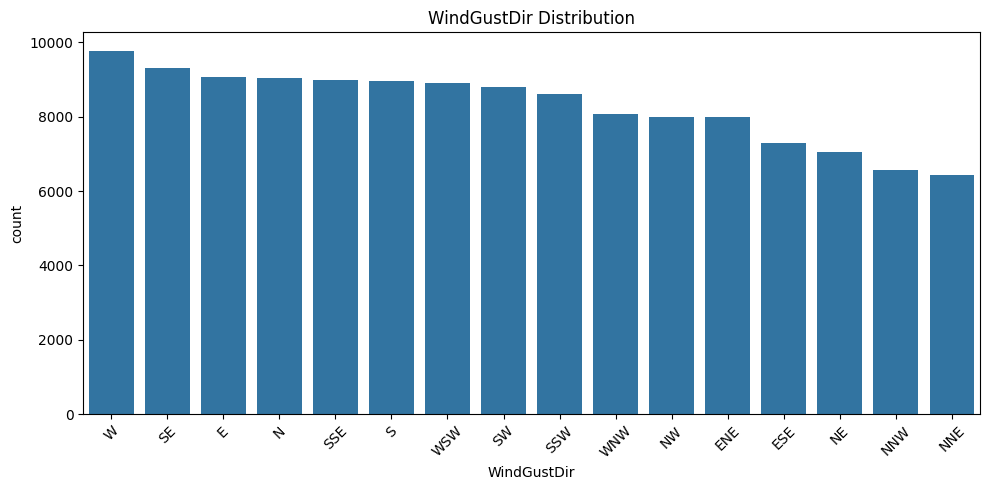

In [32]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="WindGustDir",
    order=df["WindGustDir"].value_counts().index
)

plt.title("WindGustDir Distribution")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Note`RainToday` mirrors the target's imbalance almost exactly (77.7% No / 22.3% Yes), which makes sense since both are derived from the same rainfall threshold on consecutive days. Station coverage is fairly even across `Location` (49 stations, each with roughly 3,000-3,400 observations), so no single station dominates the dataset. `WindGustDir` is close to uniformly distributed across the 16 compass directions, with a slight lean toward W, SE and E.

# Correlation Analysis

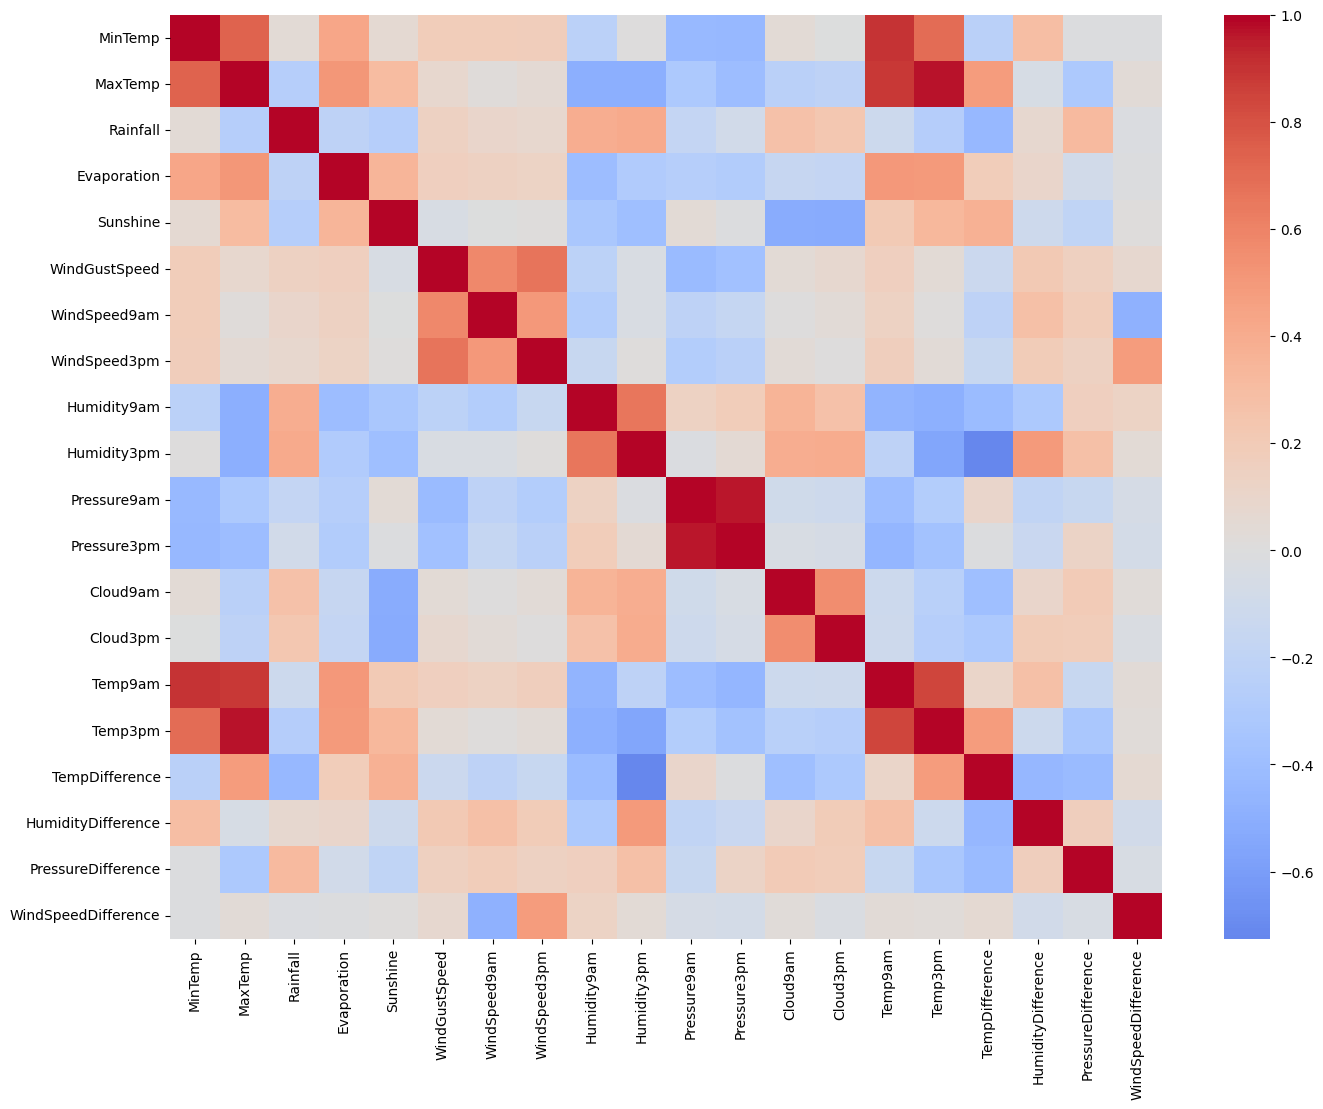

In [33]:
plt.figure(figsize=(16,12))

sns.heatmap(
    x_train[numerical_columns].corr(),
    cmap="coolwarm",
    center=0
)

plt.show()

### NoteThe strongest correlations are between same-quantity measurements taken at different times: `MaxTemp` vs `Temp3pm` (0.98), `Pressure9am` vs `Pressure3pm` (0.96), and `MinTemp` vs `Temp9am` (0.90). `Sunshine` is strongly negatively correlated with `Cloud3pm`/`Cloud9am` (~-0.70), which matches physical intuition (more cloud cover, less sunshine). This multicollinearity is expected for weather data and is handled naturally by the tree-based models; it isn't a concern for the linear models here since none of the correlated pairs are perfectly collinear.

# Data Preprocessing

In [34]:
numeric_transformer = Pipeline([
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_columns
        ),
        (
            "cat",
            categorical_transformer,
            categorical_columns
        )
    ]
)

In [36]:
print(categorical_columns)

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


# Model Evaluation Function

In [37]:
results = []

In [38]:
def evaluate_model(name, model, x_test, y_test):

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label="Yes"
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label="Yes"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label="Yes"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"{name} Finished")

    return y_pred

# Logistic Regression

In [39]:
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

In [40]:
logistic_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [41]:
logistic_pred = evaluate_model(
    "Logistic Regression",
    logistic_pipeline,
    x_test,
    y_test
)

Logistic Regression Finished


# Naive Bayes

In [42]:
naive_bayes_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        GaussianNB()
    )
])

In [43]:
naive_bayes_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier', GaussianNB())])

In [44]:
naive_bayes_pred = evaluate_model(
    "Naive Bayes",
    naive_bayes_pipeline,
    x_test,
    y_test
)

Naive Bayes Finished


# K-Nearest Neighbours

In [45]:
knn_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        KNeighborsClassifier()
    )
])

In [46]:
knn_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier', KNeighborsClassifier())])

In [47]:
knn_pred = evaluate_model(
    "KNN",
    knn_pipeline,
    x_test,
    y_test
)

KNN Finished


In [48]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795914,0.530043,0.790118,0.634463
1,Naive Bayes,0.657196,0.367769,0.736000,0.490462
2,KNN,0.841837,0.704155,0.507765,0.590047


# Decision Tree

In [49]:
decision_tree_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        )
    )
])

In [50]:
decision_tree_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [51]:
decision_tree_pred = evaluate_model(
    "Decision Tree",
    decision_tree_pipeline,
    x_test,
    y_test
)

Decision Tree Finished


# Random Forest

In [52]:
random_forest_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        )
    )
])

In [53]:
random_forest_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [54]:
random_forest_pred = evaluate_model(
    "Random Forest",
    random_forest_pipeline,
    x_test,
    y_test
)

Random Forest Finished


# Extra Trees

In [55]:
extra_trees_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        ExtraTreesClassifier(
            random_state=42,
            class_weight="balanced"
        )
    )
])

In [56]:
extra_trees_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier',
                 ExtraTreesClassifier(class_weight='balanced',
                                      random_state=42))])

In [57]:
extra_trees_pred = evaluate_model(
    "Extra Trees",
    extra_trees_pipeline,
    x_test,
    y_test
)

Extra Trees Finished


# SVC

In [58]:
svc_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LinearSVC(
            random_state=42,
            class_weight="balanced",
            max_iter=5000
        )
    )
])

In [59]:
svc_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier',
                 LinearSVC(class_weight='balanced', max_iter=5000,
                           random_state=42))])

In [60]:
svc_pred = evaluate_model(
    "SVC",
    svc_pipeline,
    x_test,
    y_test
)

SVC Finished


# Bagging

In [61]:
bagging_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        BaggingClassifier(
            random_state=42
        )
    )
])

In [62]:
bagging_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier', BaggingClassifier(random_state=42))])

In [63]:
bagging_pred = evaluate_model(
    "Bagging",
    bagging_pipeline,
    x_test,
    y_test
)

Bagging Finished


In [64]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795914,0.530043,0.790118,0.634463
1,Naive Bayes,0.657196,0.367769,0.736000,0.490462
2,KNN,0.841837,0.704155,0.507765,0.590047
3,Decision Tree,0.791097,0.534532,0.526902,0.530690
4,Random Forest,0.852737,0.781322,0.476392,0.591892
5,Extra Trees,0.855269,0.788506,0.484235,0.600000
6,SVC,0.796828,0.531631,0.786980,0.634581
7,Bagging,0.842364,0.723113,0.480941,0.577673


# AdaBoost

In [65]:
adaboost_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        AdaBoostClassifier(
            random_state=42
        )
    )
])

In [66]:
adaboost_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier', AdaBoostClassifier(random_state=42))])

In [67]:
adaboost_pred = evaluate_model(
    "AdaBoost",
    adaboost_pipeline,
    x_test,
    y_test
)

AdaBoost Finished


# Gradient Boosting

In [68]:
gradient_boosting_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        GradientBoostingClassifier(
            random_state=42
        )
    )
])

In [69]:
gradient_boosting_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [70]:
gradient_boosting_pred = evaluate_model(
    "Gradient Boosting",
    gradient_boosting_pipeline,
    x_test,
    y_test
)

Gradient Boosting Finished


# Hist Gradient Boosting

In [71]:
y_train_encoded = y_train.map(
    {
        "No":0,
        "Yes":1
    }
)

y_test_encoded = y_test.map(
    {
        "No":0,
        "Yes":1
    }
)

In [72]:
hist_gradient_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        HistGradientBoostingClassifier(
            random_state=42
        )
    )
])

In [73]:
hist_gradient_pipeline.fit(
    x_train,
    y_train_encoded
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier',
                 HistGradientBoostingClassifier(random_state=42))])

In [74]:
hist_gradient_pred = hist_gradient_pipeline.predict(
    x_test
)

hist_gradient_pred = np.where(
    hist_gradient_pred==1,
    "Yes",
    "No"
)

results.append({
    "Model":"Hist Gradient Boosting",
    "Accuracy":accuracy_score(y_test,hist_gradient_pred),
    "Precision":precision_score(y_test,hist_gradient_pred,pos_label="Yes"),
    "Recall":recall_score(y_test,hist_gradient_pred,pos_label="Yes"),
    "F1 Score":f1_score(y_test,hist_gradient_pred,pos_label="Yes")
})

print("Hist Gradient Boosting Finished")

Hist Gradient Boosting Finished


In [75]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795914,0.530043,0.790118,0.634463
1,Naive Bayes,0.657196,0.367769,0.736000,0.490462
2,KNN,0.841837,0.704155,0.507765,0.590047
3,Decision Tree,0.791097,0.534532,0.526902,0.530690
4,Random Forest,0.852737,0.781322,0.476392,0.591892
5,Extra Trees,0.855269,0.788506,0.484235,0.600000
6,SVC,0.796828,0.531631,0.786980,0.634581
7,Bagging,0.842364,0.723113,0.480941,0.577673
8,AdaBoost,0.841063,0.718389,0.478588,0.574468
9,Gradient Boosting,0.851331,0.754928,0.498667,0.600605


# XGBoost

In [76]:
xgboost_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    )
])

In [77]:
xgboost_pipeline.fit(
    x_train,
    y_train_encoded
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDiffer...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [78]:
xgboost_pred = xgboost_pipeline.predict(
    x_test
)

xgboost_pred = np.where(
    xgboost_pred==1,
    "Yes",
    "No"
)

results.append({
    "Model":"XGBoost",
    "Accuracy":accuracy_score(y_test,xgboost_pred),
    "Precision":precision_score(y_test,xgboost_pred,pos_label="Yes"),
    "Recall":recall_score(y_test,xgboost_pred,pos_label="Yes"),
    "F1 Score":f1_score(y_test,xgboost_pred,pos_label="Yes")
})

print("XGBoost Finished")

XGBoost Finished


# LightGBM

In [79]:
lightgbm_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LGBMClassifier(
            random_state=42,
            verbose=-1
        )
    )
])

In [80]:
lightgbm_pipeline.fit(
    x_train,
    y_train_encoded
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier', LGBMClassifier(random_state=42, verbose=-1))])

In [81]:
lightgbm_pred = lightgbm_pipeline.predict(
    x_test
)

lightgbm_pred = np.where(
    lightgbm_pred==1,
    "Yes",
    "No"
)

results.append({
    "Model":"LightGBM",
    "Accuracy":accuracy_score(y_test,lightgbm_pred),
    "Precision":precision_score(y_test,lightgbm_pred,pos_label="Yes"),
    "Recall":recall_score(y_test,lightgbm_pred,pos_label="Yes"),
    "F1 Score":f1_score(y_test,lightgbm_pred,pos_label="Yes")
})

print("LightGBM Finished")

LightGBM Finished


# CatBoost

In [82]:
catboost_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        CatBoostClassifier(
            random_state=42,
            verbose=0
        )
    )
])

In [83]:
catboost_pipeline.fit(
    x_train,
    y_train_encoded
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier', CatBoostClassifier(random_state=42, verbose=0))])

In [84]:
catboost_pred = catboost_pipeline.predict(
    x_test
)

catboost_pred = np.where(
    catboost_pred==1,
    "Yes",
    "No"
)

results.append({
    "Model":"CatBoost",
    "Accuracy":accuracy_score(y_test,catboost_pred),
    "Precision":precision_score(y_test,catboost_pred,pos_label="Yes"),
    "Recall":recall_score(y_test,catboost_pred,pos_label="Yes"),
    "F1 Score":f1_score(y_test,catboost_pred,pos_label="Yes")
})

print("CatBoost Finished")

CatBoost Finished


# Voting Classifier

In [85]:
voting_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        VotingClassifier(
            estimators=[
                (
                    "lr",
                    LogisticRegression(
                        random_state=42,
                        max_iter=1000
                    )
                ),
                (
                    "rf",
                    RandomForestClassifier(
                        random_state=42
                    )
                ),
                (
                    "et",
                    ExtraTreesClassifier(
                        random_state=42
                    )
                )
            ],
            voting="hard"
        )
    )
])

In [86]:
voting_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDiffer...
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier',
                 VotingClassifier(estimators=[('lr',
                                               LogisticRegression(max_iter=1000,
                                                                  random_state=42)),
                                              ('rf',
                                               RandomForestClassifier(random_state=42)),
                                              ('et',
                                               ExtraTreesClassifier(random_state=42))]))])

In [87]:
voting_pred = evaluate_model(
    "Voting",
    voting_pipeline,
    x_test,
    y_test
)

Voting Finished


# Stacking Classifier

In [88]:
stacking_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        StackingClassifier(
            estimators=[
                (
                    "lr",
                    LogisticRegression(
                        random_state=42,
                        max_iter=1000
                    )
                ),
                (
                    "rf",
                    RandomForestClassifier(
                        random_state=42
                    )
                ),
                (
                    "et",
                    ExtraTreesClassifier(
                        random_state=42
                    )
                )
            ],
            final_estimator=LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    )
])

In [89]:
stacking_pipeline.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDiffer...
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier',
                 StackingClassifier(estimators=[('lr',
                                                 LogisticRegression(max_iter=1000,
                                                                    random_state=42)),
                                                ('rf',
                                                 RandomForestClassifier(random_state=42)),
                                                ('et',
                                                 ExtraTreesClassifier(random_state=42))],
                                    final_estimator=LogisticRegression(max_iter=1000,
                                                                       random_state=42)))])

In [90]:
stacking_pred = evaluate_model(
    "Stacking",
    stacking_pipeline,
    x_test,
    y_test
)

Stacking Finished


In [91]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,CatBoost,0.863005,0.764342,0.562196,0.647867
1,XGBoost,0.859137,0.751326,0.555451,0.638709
2,Stacking,0.858926,0.754141,0.549961,0.636067
3,SVC,0.796828,0.531631,0.786980,0.634581
4,Logistic Regression,0.795914,0.530043,0.790118,0.634463
5,LightGBM,0.858750,0.756751,0.545098,0.633719
6,Hist Gradient Boosting,0.858082,0.754405,0.544000,0.632155
7,Voting,0.858153,0.789370,0.500863,0.612860
8,Gradient Boosting,0.851331,0.754928,0.498667,0.600605
9,Extra Trees,0.855269,0.788506,0.484235,0.600000


# Hyperparameter Tuning

In [92]:
from sklearn.metrics import make_scorer

In [93]:
f1_scorer = make_scorer(
    f1_score,
    pos_label="Yes"
)

In [94]:
def tune_model(
    pipeline,
    params,
    x_train,
    y_train,
    scorer
):

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        scoring=scorer,
        cv=5,
        n_jobs=-1
    )

    grid.fit(
        x_train,
        y_train
    )

    print(grid.best_params_)

    print(grid.best_score_)

    return grid

# CatBoost Hyperparameter Tuning

In [95]:
catboost_params = {

    "classifier__depth":[4,6,8],

    "classifier__learning_rate":[0.01,0.05,0.1],

    "classifier__iterations":[200,400]

}

In [96]:
catboost_grid = tune_model(
    catboost_pipeline,
    catboost_params,
    x_train,
    y_train_encoded,
    make_scorer(
        f1_score,
        pos_label=1
    )
)

{'classifier__depth': 8, 'classifier__iterations': 400, 'classifier__learning_rate': 0.1}
0.6450900354873447


In [97]:
catboost_grid.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier',
                 CatBoostClassifier(depth=8, iterations=400, learning_rate=0.1, random_state=42, verbose=0))])

In [98]:


catboost_grid.best_score_

np.float64(0.6450900354873447)

In [99]:
catboost_grid.best_params_

{'classifier__depth': 8,
 'classifier__iterations': 400,
 'classifier__learning_rate': 0.1}

# XGBoost Hyperparameter Tuning

In [100]:
xgboost_params = {

    "classifier__n_estimators":[200,400],

    "classifier__max_depth":[4,6,8],

    "classifier__learning_rate":[0.01,0.05,0.1]

}

In [101]:
xgboost_grid = tune_model(
    xgboost_pipeline,
    xgboost_params,
    x_train,
    y_train_encoded,
    make_scorer(f1_score, pos_label=1)
)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__n_estimators': 400}
0.6510817389010704


In [102]:
xgboost_grid.best_params_


{'classifier__learning_rate': 0.1,
 'classifier__max_depth': 8,
 'classifier__n_estimators': 400}

In [103]:
xgboost_grid.best_score_

np.float64(0.6510817389010704)

# Hyperparameter Tuning results

GridSearchCV was applied on the two best-performing models based on the F1 Score.

The tuning process optimized the model hyperparameters using 5-Fold Cross Validation with F1 Score as the evaluation metric.

## CatBoost Best Parameters

- iterations = 400
- depth = 8
- learning_rate = 0.1

Best Cross Validation F1 Score = 0.6451

## XGBoost Best Parameters

- n_estimators = 400
- max_depth = 8
- learning_rate = 0.1

Best Cross Validation F1 Score = 0.6511

### Note

Both models achieved very similar performance after tuning.

Although XGBoost achieved a slightly higher cross-validation F1 Score, CatBoost achieved the highest test-set F1 Score during model evaluation.

Therefore, CatBoost is selected as the final model.

In [104]:
best_catboost = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        CatBoostClassifier(
            iterations=400,
            depth=8,
            learning_rate=0.1,
            random_state=42,
            verbose=0
        )
    )
])

best_catboost.fit(
    x_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'TempDifference',
                                                   'HumidityDifference',
                                                   'PressureDifference',
                                                   'WindSpeedDifference']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainToday'])])),
                ('classifier',
                 CatBoostClassifier(depth=8, iterations=400, learning_rate=0.1, random_state=42, verbose=0))])

# Feature Importance

The importance of each feature was extracted from the final CatBoost model to identify the most influential variables affecting rainfall prediction.

In [105]:
feature_names = best_catboost.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": best_catboost.named_steps[
            "classifier"
        ].feature_importances_
    }
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
9,num__Humidity3pm,15.816035
11,num__Pressure3pm,7.778730
5,num__WindGustSpeed,7.236413
18,num__PressureDifference,6.256203
4,num__Sunshine,5.007747
0,num__MinTemp,3.125292
2,num__Rainfall,3.024738
8,num__Humidity9am,2.969506
17,num__HumidityDifference,2.907405
14,num__Temp9am,2.900002


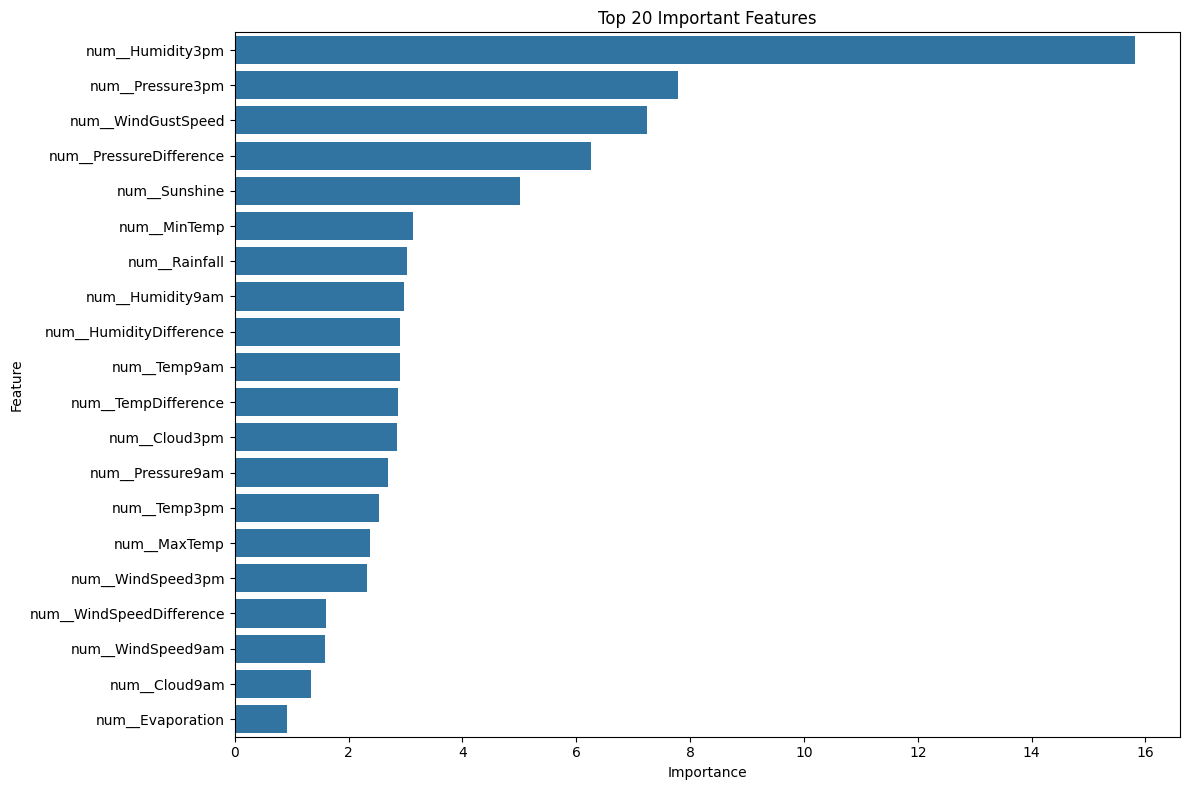

In [106]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Important Features"
)

plt.tight_layout()

plt.show()

### Note

Humidity at 3 PM is the most influential feature for predicting rainfall.

Pressure, wind speed, sunshine, and temperature-related features also contribute significantly to the model performance.

Some features have relatively low importance, but they were retained to preserve the overall model performance.

# Feature Selection

Feature importance was analyzed using the final CatBoost model.

No features were removed because the final model already achieved the highest F1 Score using the complete feature set.

The feature importance analysis was used for interpretation rather than feature elimination.

# Final Evaluation

The final CatBoost model was evaluated using multiple evaluation metrics to assess its performance on unseen test data.

In [107]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [108]:
final_predictions = best_catboost.predict(
    x_test
)

In [109]:
print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

          No       0.88      0.95      0.92     22064
         Yes       0.77      0.56      0.65      6375

    accuracy                           0.86     28439
   macro avg       0.82      0.76      0.78     28439
weighted avg       0.86      0.86      0.85     28439



### Note

The classification report summarizes the Precision, Recall and F1 Score for both classes.

The F1 Score was selected as the primary evaluation metric because the dataset is moderately imbalanced.

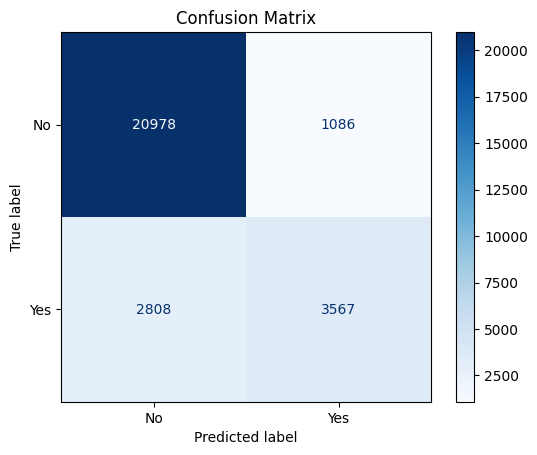

In [110]:
cm = confusion_matrix(
    y_test,
    final_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_catboost.classes_
)

disp.plot(
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [111]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

In [112]:
probabilities = best_catboost.predict_proba(
    x_test
)[:,1]

In [113]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities,
    pos_label="Yes"
)

auc = roc_auc_score(
    y_test,
    probabilities
)

print(auc)

0.8985343386085399


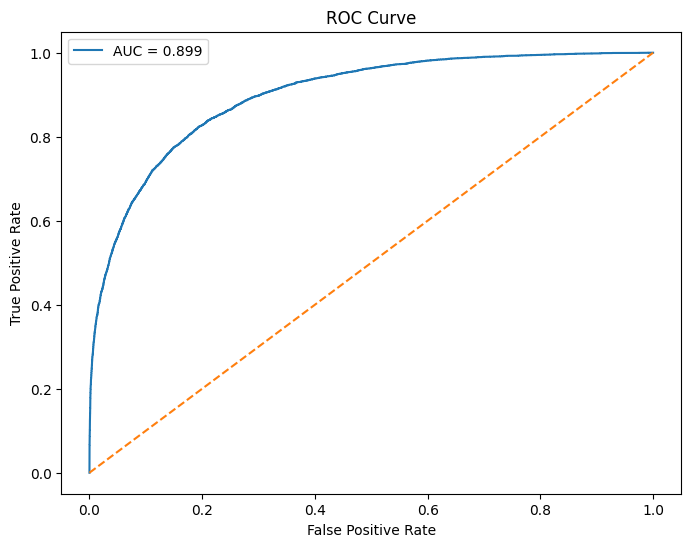

In [114]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Note

The ROC Curve illustrates the trade-off between the True Positive Rate and the False Positive Rate.

The AUC Score summarizes the overall classification performance.

A higher AUC indicates better discrimination between rainy and non-rainy days.

# Model Saving

The final CatBoost model was saved using Pickle to be used later in the Streamlit application.

In [115]:
import pickle

In [116]:
with open(
    "rain_prediction_model.pkl",
    "wb"
) as file:

    pickle.dump(
        best_catboost,
        file
    )

In [117]:
with open(
    "rain_prediction_model.pkl",
    "rb"
) as file:

    loaded_model = pickle.load(file)

In [118]:
loaded_predictions = loaded_model.predict(
    x_test
)

print(
    loaded_predictions[:10]
)

['No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No']


In [119]:
import sklearn

print(sklearn.__version__)

1.6.1
